In [1]:
d = 251
print(381520/d) 
print(95380/d)

1520.0
380.0


In [2]:
380*4


1520

In [3]:
import json
import subprocess
import re
from itertools import product
import xarray as xr
import pandas as pd
from pathlib import Path
import os
import numpy as np
import matplotlib.pyplot as plt


#with open("dpa_tune_settings.json", 'r') as file:
#        settings = json.load(file)

#print("output_dir:", settings['output_dir'])
#alt_output_dir = "/work/fl53wumy-llaae_data_new/fl53wumy-llaae_data_new-1748049607/dpa_output/dpa_tuning_output_missed_jobs/"
#print("alternative output_dir:", alt_output_dir)


In [4]:
# MAKE SURE THESE ARE CORRECTLY DEFINED
#latent_dims=[10, 20, 50]
#encoder=["learnable", "PCA"]
#hidden_dim_NNs=[50, 100]
#num_layers_NNs=[4, 6]
#noise_dim_dec=[5, 10, 20]
# latent map
#hidden_dim_lm=[20, 50]
#noise_dim_lm=[20, 100]
#training
#lambdas=[0.0, 0.5, 1.0]

###

output_dir = "/work/fl53wumy-dpa_data/fl53wumy-llaae_data_new_22092025-1763346001/fl53wumy-llaae_data_new-1758244802/fl53wumy-llaae_data_new-1748049607/dpa_output/dpa_tuning3_starting11122025_v4_data/"
# 1) Define your coordinate values
coords = {
    'latent_dim':    [20, 50, 100],
    'encoder':       ['learnable', 'PCA'],
    'hidden_dim_NN': [50, 100],
    'num_layers_NN': [4, 6, 10],
    'noise_dim_dec': [5, 20, 100],
    'hidden_dim_lm': [50, 100],
    'noise_dim_lm':  [20, 100],
    'lamb':          [0.5],
    'epoch':         np.arange(1, 101),          # 0 … 100 inclusive
    'batch_norm':    ["False"],
    'alpha':         [0.5, 1.0, 1.5],
    'mode':          ['train', 'test'],
    'loss':          ['Total loss','Total S1','Total S2',
                      'DPA NRGY','DPA s1','DPA s2',
                      'LM NRGY','LM s1','LM s1']
}


#save_dir = f"{settings['output_dir']}_{latent_dim}_{num_layers}_{hidden_dim}_{noise_dim_dec}_{in_dim_lm}_{noise_dim_lm}_{num_layers_lm}_{hidden_dim_lm}_encoderis{encoder}_lambda{lam}/"

In [5]:
# Generate all combinations as tuples
combos = list(product(
    coords['latent_dim'],
    coords['encoder'],
    coords['hidden_dim_NN'],
    coords['num_layers_NN'],
    coords['noise_dim_dec'],
    coords['hidden_dim_lm'],
    coords['noise_dim_lm'],
    coords['lamb'],
    coords['batch_norm'],
    coords['alpha']
))

# If you prefer a list of dicts:
param_names = [
    "latent_dim", "encoder", "hidden_dim_NN", "num_layers_NN",
    "noise_dim_dec", "hidden_dim_lm", "noise_dim_lm", "lambda", "batch_norm", "alpha"
]
combo_dicts = [dict(zip(param_names, vals)) for vals in combos]

In [6]:
combo_dicts

[{'latent_dim': 20,
  'encoder': 'learnable',
  'hidden_dim_NN': 50,
  'num_layers_NN': 4,
  'noise_dim_dec': 5,
  'hidden_dim_lm': 50,
  'noise_dim_lm': 20,
  'lambda': 0.5,
  'batch_norm': 'False',
  'alpha': 0.5},
 {'latent_dim': 20,
  'encoder': 'learnable',
  'hidden_dim_NN': 50,
  'num_layers_NN': 4,
  'noise_dim_dec': 5,
  'hidden_dim_lm': 50,
  'noise_dim_lm': 20,
  'lambda': 0.5,
  'batch_norm': 'False',
  'alpha': 1.0},
 {'latent_dim': 20,
  'encoder': 'learnable',
  'hidden_dim_NN': 50,
  'num_layers_NN': 4,
  'noise_dim_dec': 5,
  'hidden_dim_lm': 50,
  'noise_dim_lm': 20,
  'lambda': 0.5,
  'batch_norm': 'False',
  'alpha': 1.5},
 {'latent_dim': 20,
  'encoder': 'learnable',
  'hidden_dim_NN': 50,
  'num_layers_NN': 4,
  'noise_dim_dec': 5,
  'hidden_dim_lm': 50,
  'noise_dim_lm': 100,
  'lambda': 0.5,
  'batch_norm': 'False',
  'alpha': 0.5},
 {'latent_dim': 20,
  'encoder': 'learnable',
  'hidden_dim_NN': 50,
  'num_layers_NN': 4,
  'noise_dim_dec': 5,
  'hidden_dim_lm':

In [7]:
def load_and_validate(path, validator):
    """
    Load the file at `path` and run `validator(obj)`.
    Raise FileNotFoundError if missing, or ValueError if validator fails.
    """
    if not os.path.exists(path):
        raise FileNotFoundError(f"No such file: {path}")
    
    # Example for JSON; swap out for pd.read_csv, pickle.load, etc.
    #with open(path, 'r') as f:
        #obj = json.load(f)
    df = pd.read_csv(
            path,
            skipinitialspace=True,
            dtype={'Epoch': str}
        )

    if not validator(df):
        raise ValueError(f"Validation failed for file: {path}")
    df_data = get_train_test(df)
    return df_data

def get_train_test(df):
    # split into Train vs Test
    is_train = df['Epoch'].str.startswith('Train')
    is_test  = df['Epoch'].str.startswith('Test')

    train_df = df[is_train].reset_index(drop=True)
    test_df  = df[is_test].reset_index(drop=True)

    # get numeric columns and arrays
    numeric_cols = df.columns.drop('Epoch')
    train_array = train_df[numeric_cols].to_numpy()
    test_array  = test_df[numeric_cols].to_numpy()
    return train_array, test_array

# --- Your custom validation function ---
def col_no(df):
    train_array, test_array = get_train_test(df)
    
    if test_array.shape[0] == 100:
        prop = True
    else:
        print(f"[{i}] Test array length: {test_array.shape[0]}")
        prop = False
    return prop

In [14]:
# 2) Create an empty Dataset filled with NaNs
ds = xr.Dataset(
    coords={k: ( [k], v ) for k, v in coords.items()},
    data_vars={
        'value': ( list(coords.keys()), 
                   np.full([len(v) for v in coords.values()], np.nan) )
    }
)
# dims of ds['value'] are in the order of coords.keys()

# 3) Function to parse hyperparameters from filename
def parse_filename(fname):
    """
    example filename:
    _10_4_50_10_1001_20_2_50_encoderislearnable_lambda0.0
    _latentdim(0)_numlayers(1)_hiddendim(2)_noisedimdec(3)_indimlm(4)_noisedimlm(5)_numlayerslm(6)_hiddendimlm(7)_encoder(8)_lambda(9)
    Expect filenames like:
      '..._10_PCA_50_4_5_20_20_20_0.5.txt'
    in exactly the same order as coords (except epoch/mode/loss).
    """
    stem = Path(fname).name
    print(stem)
    parts = stem.split('_')
    print("Parts:", parts)
    #print(str(parts[8+1].split('is')[1]))
    print("lambda:", parts[9+1].split('bda')[1])
    return {
        'latent_dim':    int(parts[0+1]),
        'num_layers_NN': int(parts[1+1]),
        'hidden_dim_NN': int(parts[2+1]),
        'noise_dim_dec': int(parts[3+1]),
        'hidden_dim_lm': int(parts[7+1]),
        'noise_dim_lm':  int(parts[5+1]),
        'encoder':       str(parts[8+1].split('is')[1]),
        'lambda':        float(parts[9+1].split('bda')[1]),
        'batch_norm':    str(parts[12+1].split('bnis')[1]),
        'alpha':         float(parts[10+1].split('lpha')[1])
    }
    


In [18]:
i = 1
while i < 1296:
    print(i)
    save_path = (
        f"{output_dir}_"
        f"{combo_dicts[i]['latent_dim']}_"
        f"{combo_dicts[i]['num_layers_NN']}_"
        f"{combo_dicts[i]['hidden_dim_NN']}_"
        f"{combo_dicts[i]['noise_dim_dec']}_1001_"
        f"{combo_dicts[i]['noise_dim_lm']}_2_"
        f"{combo_dicts[i]['hidden_dim_lm']}_"
        f"encoderislearnable_"
        #f"encoderis{combo_dicts[i]['encoder']}_"
        f"lambda{combo_dicts[i]['lambda']}_alpha{combo_dicts[i]['alpha']}_bs128_bnis{combo_dicts[i]['batch_norm']}/log.txt"
    )
    df = load_and_validate(save_path, col_no)
    file_path = Path(save_path)
    
    train_losses = df[0]
    if np.isnan(train_losses).any():
        print("Contains NaN?", np.isnan(train_losses).any(), np.isnan(train_losses).sum())
    test_losses = df[1]
    if np.isnan(test_losses).any():
        print("Contains NaN?", np.isnan(test_losses).any(), np.isnan(test_losses).sum())

    #print(train_losses.shape, test_losses.shape)
    #print("filepath:", file_path.parent)
    params = parse_filename(file_path.parent)

    ###
    # train values
    ds['value'].loc[
        dict(
            latent_dim=params['latent_dim'],
            encoder=params['encoder'],
            hidden_dim_NN=params['hidden_dim_NN'],
            num_layers_NN=params['num_layers_NN'],
            noise_dim_dec=params['noise_dim_dec'],
            hidden_dim_lm=params['hidden_dim_lm'],
            noise_dim_lm=params['noise_dim_lm'],
            lamb=params['lambda'],
            alpha=params['alpha'],
            batch_norm=params['batch_norm'],
            mode="train",
        )
    ] = train_losses
    
    # test values
    ds['value'].loc[
        dict(
            latent_dim=params['latent_dim'],
            encoder=params['encoder'],
            hidden_dim_NN=params['hidden_dim_NN'],
            num_layers_NN=params['num_layers_NN'],
            noise_dim_dec=params['noise_dim_dec'],
            hidden_dim_lm=params['hidden_dim_lm'],
            noise_dim_lm=params['noise_dim_lm'],
            lamb=params['lambda'],
            alpha=params['alpha'],
            batch_norm=params['batch_norm'],
            mode="test",
        )
    ] = test_losses

    ###
    i += 1

1
_20_4_50_5_1001_20_2_50_encoderislearnable_lambda0.5_alpha1.0_bs128_bnisFalse
Parts: ['', '20', '4', '50', '5', '1001', '20', '2', '50', 'encoderislearnable', 'lambda0.5', 'alpha1.0', 'bs128', 'bnisFalse']
lambda: 0.5
2
_20_4_50_5_1001_20_2_50_encoderislearnable_lambda0.5_alpha1.5_bs128_bnisFalse
Parts: ['', '20', '4', '50', '5', '1001', '20', '2', '50', 'encoderislearnable', 'lambda0.5', 'alpha1.5', 'bs128', 'bnisFalse']
lambda: 0.5
3
_20_4_50_5_1001_100_2_50_encoderislearnable_lambda0.5_alpha0.5_bs128_bnisFalse
Parts: ['', '20', '4', '50', '5', '1001', '100', '2', '50', 'encoderislearnable', 'lambda0.5', 'alpha0.5', 'bs128', 'bnisFalse']
lambda: 0.5
4
_20_4_50_5_1001_100_2_50_encoderislearnable_lambda0.5_alpha1.0_bs128_bnisFalse
Parts: ['', '20', '4', '50', '5', '1001', '100', '2', '50', 'encoderislearnable', 'lambda0.5', 'alpha1.0', 'bs128', 'bnisFalse']
lambda: 0.5
5
_20_4_50_5_1001_100_2_50_encoderislearnable_lambda0.5_alpha1.5_bs128_bnisFalse
Parts: ['', '20', '4', '50', '5', '

In [ ]:
#old
i = 1
while i < 1297:
    print(i)
    save_path = (
        f"{output_dir}_"
        f"{combo_dicts[i]['latent_dim']}_"
        f"{combo_dicts[i]['num_layers_NN']}_"
        f"{combo_dicts[i]['hidden_dim_NN']}_"
        f"{combo_dicts[i]['noise_dim_dec']}_1001_"
        f"{combo_dicts[i]['noise_dim_lm']}_2_"
        f"{combo_dicts[i]['hidden_dim_lm']}_"
        f"encoderislearnable_"
        #f"encoderis{combo_dicts[i]['encoder']}_"
        f"lambda{combo_dicts[i]['lambda']}_alpha{combo_dicts[i]['alpha']}_bs128_bnis{combo_dicts[i]['batch_norm']}/log.txt"
    )
    df = load_and_validate(save_path, col_no)
    file_path = Path(save_path)
    
    train_losses = df[0]
    if np.isnan(train_losses).any():
        print("Contains NaN?", np.isnan(train_losses).any(), np.isnan(train_losses).sum())
    test_losses = df[1]
    if np.isnan(test_losses).any():
        print("Contains NaN?", np.isnan(test_losses).any(), np.isnan(test_losses).sum())

    #print(train_losses.shape, test_losses.shape)
    #print("filepath:", file_path.parent)
    params = parse_filename(file_path.parent)

    ###
    # train values
    ds['value'].loc[
        dict(
          latent_dim=params['latent_dim'],
          encoder=params['encoder'],
          hidden_dim_NN=params['hidden_dim_NN'],
          num_layers_NN=params['num_layers_NN'],
          noise_dim_dec=params['noise_dim_dec'],
          hidden_dim_lm=params['hidden_dim_lm'],
          noise_dim_lm=params['noise_dim_lm'],
          lamb=params['lambda'],
          alpha=['alpha'],
          batch_norm=['batch_norm'],
          mode="train",
          #epoch=epoch,
          #loss=loss_name
        )
    ] = train_losses
    ###
    # test loss
    ds['value'].loc[
        dict(
          latent_dim=params['latent_dim'],
          encoder=params['encoder'],
          hidden_dim_NN=params['hidden_dim_NN'],
          num_layers_NN=params['num_layers_NN'],
          noise_dim_dec=params['noise_dim_dec'],
          hidden_dim_lm=params['hidden_dim_lm'],
          noise_dim_lm=params['noise_dim_lm'],
          lamb=params['lambda'],
          mode="test",
          #epoch=epoch,
          #loss=loss_name
        )
    ] = test_losses
    ###
    i += 1

In [ ]:
i = 1
while i < 864:
    print(i)
    save_path = (
        f"{settings['output_dir']}_"
        f"{combo_dicts[i]['latent_dim']}_"
        f"{combo_dicts[i]['num_layers_NN']}_"
        f"{combo_dicts[i]['hidden_dim_NN']}_"
        f"{combo_dicts[i]['noise_dim_dec']}_1001_"
        f"{combo_dicts[i]['noise_dim_lm']}_2_"
        f"{combo_dicts[i]['hidden_dim_lm']}_"
        f"encoderis{combo_dicts[i]['encoder']}_"
        f"lambda{combo_dicts[i]['lambda']}/log.txt"
    )

    alt_save_path = (
        f"{alt_output_dir}_"
        f"{combo_dicts[i]['latent_dim']}_"
        f"{combo_dicts[i]['num_layers_NN']}_"
        f"{combo_dicts[i]['hidden_dim_NN']}_"
        f"{combo_dicts[i]['noise_dim_dec']}_1001_"
        f"{combo_dicts[i]['noise_dim_lm']}_2_"
        f"{combo_dicts[i]['hidden_dim_lm']}_"
        f"encoderis{combo_dicts[i]['encoder']}_"
        f"lambda{combo_dicts[i]['lambda']}/log.txt"
    )
    # --- Load with fallback logic ---
    try:
        df = load_and_validate(save_path, col_no)
        #print(f"Loaded primary logs: {save_path}")
        file_path = Path(save_path)
    
    except (FileNotFoundError, ValueError) as e:
        print(f"[WARN] Primary failed ({e}); loading fallback.")
        print(f"Loading fallback logs: {alt_save_path}")
        df = load_and_validate(alt_save_path, col_no)
        file_path = Path(alt_save_path)
        #print(f"Loaded fallback logs: {alt_save_path}")
    
    train_losses = df[0]
    if np.isnan(train_losses).any():
        print("Contains NaN?", np.isnan(train_losses).any(), np.isnan(train_losses).sum())
    test_losses = df[1]
    if np.isnan(test_losses).any():
        print("Contains NaN?", np.isnan(test_losses).any(), np.isnan(test_losses).sum())

    #print(train_losses.shape, test_losses.shape)
    #print("filepath:", file_path.parent)
    params = parse_filename(file_path.parent)

    ###
    # train values
    ds['value'].loc[
        dict(
          latent_dim=params['latent_dim'],
          encoder=params['encoder'],
          hidden_dim_NN=params['hidden_dim_NN'],
          num_layers_NN=params['num_layers_NN'],
          noise_dim_dec=params['noise_dim_dec'],
          hidden_dim_lm=params['hidden_dim_lm'],
          noise_dim_lm=params['noise_dim_lm'],
          lamb=params['lambda'],
          mode="train",
          #epoch=epoch,
          #loss=loss_name
        )
    ] = train_losses
    ###
    # test loss
    ds['value'].loc[
        dict(
          latent_dim=params['latent_dim'],
          encoder=params['encoder'],
          hidden_dim_NN=params['hidden_dim_NN'],
          num_layers_NN=params['num_layers_NN'],
          noise_dim_dec=params['noise_dim_dec'],
          hidden_dim_lm=params['hidden_dim_lm'],
          noise_dim_lm=params['noise_dim_lm'],
          lamb=params['lambda'],
          mode="test",
          #epoch=epoch,
          #loss=loss_name
        )
    ] = test_losses
    ###
    i += 1
    
    # Now `config` is guaranteed to be a valid object

In [ ]:
ds.value.sel(latent_dim = 10,
             encoder = 'learnable',
             hidden_dim_NN = 50,
             num_layers_NN = 4,
             noise_dim_dec = 10,
             hidden_dim_lm = 20,
             noise_dim_lm = 100,
             lamb = 0.0,
             mode = 'test',
             loss = 'LM NRGY'
            ).plot()

In [20]:
ds

<xarray.Dataset> Size: 19MB
Dimensions:        (latent_dim: 3, encoder: 2, hidden_dim_NN: 2,
                    num_layers_NN: 3, noise_dim_dec: 3, hidden_dim_lm: 2,
                    noise_dim_lm: 2, lamb: 1, epoch: 100, batch_norm: 1,
                    alpha: 3, mode: 2, loss: 9)
Coordinates: (12/13)
  * latent_dim     (latent_dim) int64 24B 20 50 100
  * encoder        (encoder) <U9 72B 'learnable' 'PCA'
  * hidden_dim_NN  (hidden_dim_NN) int64 16B 50 100
  * num_layers_NN  (num_layers_NN) int64 24B 4 6 10
  * noise_dim_dec  (noise_dim_dec) int64 24B 5 20 100
  * hidden_dim_lm  (hidden_dim_lm) int64 16B 50 100
    ...             ...
  * lamb           (lamb) float64 8B 0.5
  * epoch          (epoch) int64 800B 1 2 3 4 5 6 7 8 ... 94 95 96 97 98 99 100
  * batch_norm     (batch_norm) <U5 20B 'False'
  * alpha          (alpha) float64 24B 0.5 1.0 1.5
  * mode           (mode) <U5 40B 'train' 'test'
  * loss           (loss) <U10 360B 'Total loss' 'Total S1' ... 'LM s1' 'LM s1'
Data variables:
    value          (latent_dim, encoder, hidden_dim_NN, num_layers_NN, noise_dim_dec, hidden_dim_lm, noise_dim_lm, lamb, epoch, batch_norm, alpha, mode, loss) float64 19MB ...

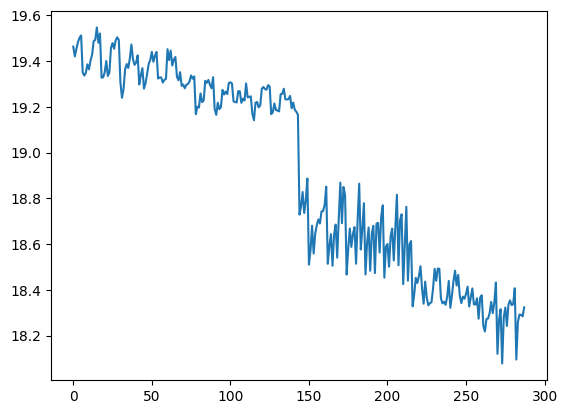

In [30]:
plt.plot(ds.value.sel(loss = "LM NRGY", epoch=100, encoder='learnable', mode='test').values.flatten())

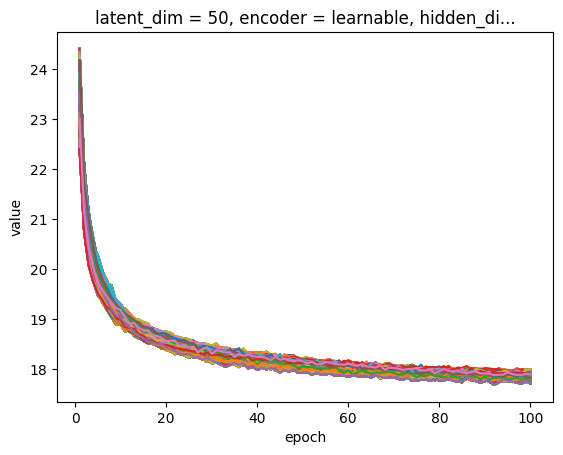

In [28]:
# 1) Turn it into a pandas Series with a MultiIndex
ser = ds.value.sel(loss = 'LM NRGY', mode = 'test', lamb = [0.5]).to_series()

# 2) Pick off the 5 smallest values
smallest = ser.nsmallest(1297)

# 3) `smallest` is a Series whose index is a tuple of coordinate labels
for coord_tuple, value in smallest.items():
    coords = dict(zip(ds.value.dims, coord_tuple))
    epoch = coords.pop('epoch')
    ds.value.sel(coords).sel(loss = 'LM NRGY', mode = 'test').plot(label = f"num_layers_NN:{coords['num_layers_NN']}, hidden_dim_lm:{coords['hidden_dim_lm']}, lambda:{coords['lamb']}")
    #plt.show()
    #plt.legend()
    #print(f"value={value:.4f} at {coords}")
plt.show()




In [23]:
# search for smallest loss value
# vary remaining parameters around it

In [24]:
smallest

latent_dim  encoder    hidden_dim_NN  num_layers_NN  noise_dim_dec  hidden_dim_lm  noise_dim_lm  lamb  epoch  batch_norm  alpha
100         learnable  100            10             100            50             100           0.5   92     False       1.5      17.6906
                                                                                                       98     False       1.5      17.7130
                                                                                                       100    False       1.5      17.7210
                                                     20             50             100           0.5   92     False       1.5      17.7323
                                                     100            50             100           0.5   89     False       1.5      17.7329
                                                                                                                                    ...   
50          learnable  100            

In [20]:
type(smallest)

pandas.core.series.Series